
# Triadic Cell Notebook v18
## Tail-preserving continuous compilation runtime

This notebook implements the next architectural turn:

- keep **semantic collapse** separate from **tail memory**
- model the runtime as **vary → project → validate → promote / retire**
- treat the **tail** as the first executable projection, not as disposable residue
- make dynamics **compile minus retire**

The runtime keeps four explicit stores:

1. **provisional bank**
   - candidates not yet validated

2. **promoted bank**
   - only tails that cleared validation

3. **retire ledger**
   - failed candidate burden and rewrite scar

4. **tail log**
   - ordered compile history for each candidate:
     cue, route, margin, compile metrics, promoted/retired status

The goal is not just recall.
The goal is to preserve:
- what collapsed
- how it collapsed
- what failed
- what got promoted



## Runtime grammar used here

The runtime is implemented as:

$$
\text{vary} \to \text{project} \to \text{tail} \to V \to \text{promote or retire}
$$

A candidate tail is validated by a surrogate compile predicate:

- low contradiction
- good reproducibility
- bounded budget
- low collateral spill

Only promoted tails go into the promoted bank.
Failed tails feed the retire ledger.

This is the first notebook in the series that treats the tail as a first-class object.


In [1]:

from __future__ import annotations

from dataclasses import dataclass, asdict
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class RuntimeState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)

    def copy(self):
        return RuntimeState(
            coherence=float(self.coherence),
            latent=self.latent.copy(),
            readout=self.readout.copy(),
        )


@dataclass
class TailRecord:
    episode: int
    trial: int
    target_slot: int
    predicted_slot: int
    route_margin: float
    contradiction: float
    reproducibility_error: float
    budget: float
    spill: float
    compile_score: float
    promoted: bool
    retired: bool


In [3]:

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))


def top2_margin(scores: np.ndarray):
    order = np.argsort(scores)[::-1]
    top1_idx = int(order[0])
    top1 = float(scores[order[0]])
    top2 = float(scores[order[1]]) if len(order) > 1 else 0.0
    return top1_idx, top1, top1 - top2


In [4]:

class AddressBank:
    def __init__(self, width: int = 4, leak: float = 0.015):
        self.width = width
        self.leak = float(leak)

        self.keys = np.array([
            [1.0, 0.2, 0.0, 0.0],
            [0.0, 1.0, 0.2, 0.0],
            [0.2, 0.0, 1.0, 0.2],
            [0.0, 0.2, 0.0, 1.0],
        ], dtype=float)
        self.keys = self.keys / np.linalg.norm(self.keys, axis=1, keepdims=True)

        self.slots = np.zeros((4, width), dtype=float)

    @staticmethod
    def _softmax(x: np.ndarray, temp: float = 0.08) -> np.ndarray:
        z = (x - np.max(x)) / max(temp, 1e-8)
        e = np.exp(z)
        return e / np.sum(e)

    def address(self, query: np.ndarray, content_mix: float = 0.15) -> np.ndarray:
        q = query / (np.linalg.norm(query) + 1e-8)
        key_scores = self.keys @ q

        if np.any(self.slots > 0):
            slot_norms = np.linalg.norm(self.slots, axis=1, keepdims=True) + 1e-8
            slot_dirs = self.slots / slot_norms
            content_scores = slot_dirs @ q
        else:
            content_scores = np.zeros_like(key_scores)

        scores = (1.0 - content_mix) * key_scores + content_mix * content_scores
        return self._softmax(scores)

    def read(self, weights: np.ndarray) -> np.ndarray:
        return weights @ self.slots

    def write(self, weights: np.ndarray, value: np.ndarray, strength: float, topk: int = 1):
        before = self.slots.copy()
        self.slots *= (1.0 - self.leak)

        idx = np.argsort(weights)[::-1][:topk]
        masked = np.zeros_like(weights)
        masked[idx] = weights[idx]
        if masked.sum() > 0:
            masked = masked / masked.sum()

        for i in range(self.slots.shape[0]):
            self.slots[i] = np.clip(
                self.slots[i] + strength * masked[i] * value,
                0.0,
                1.0,
            )

        delta = self.slots - before
        return masked.copy(), delta

    def decay(self, amount: float):
        self.slots *= max(0.0, 1.0 - amount)

    def slot_energy(self) -> np.ndarray:
        return self.slots.mean(axis=1)

    def copy(self):
        return copy.deepcopy(self)


In [5]:

class TailCompilerCell:
    def __init__(self, B: float = 1.0, T: float = 1.0, R: float = 1.0):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

        self.W_query = np.array([
            [1.0, 0.0, 0.3, 0.0],
            [0.0, 1.0, 0.0, 0.4],
            [0.3, 0.0, 1.0, 0.0],
            [0.0, 0.4, 0.0, 1.0],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def _query(self, latent: np.ndarray) -> np.ndarray:
        raw_query = self.W_query @ latent
        return raw_query / (np.linalg.norm(raw_query) + 1e-8)

    def project_tail(self, state: RuntimeState, drive_vec: np.ndarray, context: np.ndarray):
        composite_target = 0.72 * drive_vec + 0.28 * context

        follow = 0.20 * self.B * self.T * state.coherence * (composite_target - state.latent)
        static_drag = 0.04 * (1.0 - self.T) * (state.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * state.latent
        latent = self._clip(state.latent + follow - static_drag - unsupported_loss)

        delta_vec = np.abs(latent - state.latent)
        support = self.B * self.T * self.R * state.coherence

        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * state.readout
        readout = self._clip(0.82 * state.readout + 2.25 * support * projected - shell_decay)

        budget = float(delta_vec.mean())
        return latent, readout, delta_vec, budget

    def step(self, state: RuntimeState, drive_vec: np.ndarray, bank_context: np.ndarray):
        load = np.linalg.norm(state.readout) + 0.2 * np.linalg.norm(bank_context)
        coherence_restore = 0.05 * self.B * (0.84 - state.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.008 * load
        coherence = float(np.clip(state.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        temp_state = RuntimeState(coherence=coherence, latent=state.latent.copy(), readout=state.readout.copy())
        latent, readout, delta_vec, budget = self.project_tail(temp_state, drive_vec, bank_context)

        next_state = RuntimeState(coherence=coherence, latent=latent, readout=readout)
        return next_state, delta_vec, budget


In [6]:

patterns = np.array([
    [1.00, 0.05, 0.05, 0.05],
    [0.05, 1.00, 0.05, 0.05],
    [0.05, 0.05, 1.00, 0.05],
    [0.05, 0.05, 0.05, 1.00],
], dtype=float)

def partial_cue(pattern: np.ndarray, mask_prob: float = 0.5, noise: float = 0.04) -> np.ndarray:
    cue = pattern.copy()
    mask = rng.random(pattern.shape[0]) < mask_prob
    cue[mask] = 0.0
    cue += rng.normal(0.0, noise, size=cue.shape[0])
    return np.clip(cue, 0.0, 1.0)


In [7]:

class ContinuousCompilationRuntime:
    def __init__(self):
        self.cell = TailCompilerCell()
        self.provisional_bank = AddressBank(width=4, leak=0.020)
        self.promoted_bank = AddressBank(width=4, leak=0.010)
        self.retire_ledger = np.zeros(4, dtype=float)
        self.state = RuntimeState()
        self.tail_log = []

    def _validate_tail(
        self,
        target_slot: int,
        target_pattern: np.ndarray,
        tail_vec: np.ndarray,
        route_margin: float,
        delta_vec: np.ndarray,
        budget: float,
        episode: int,
        trial: int,
        predicted_slot: int,
    ):
        contradiction = 1.0 - cosine_similarity(tail_vec, target_pattern)

        repro_cue = target_pattern.copy()
        latent2, readout2, _, _ = self.cell.project_tail(
            self.state.copy(),
            repro_cue,
            tail_vec,
        )
        repro_tail = np.array([readout2[0], readout2[1], latent2.mean(), tail_vec.mean()], dtype=float)
        reproducibility_error = 1.0 - cosine_similarity(
            tail_vec / (np.linalg.norm(tail_vec) + 1e-8),
            repro_tail / (np.linalg.norm(repro_tail) + 1e-8),
        )

        target_change = float(np.abs(delta_vec).mean())
        collateral = float(self.retire_ledger.mean())
        spill = float(collateral / (target_change + 1e-8))

        compile_score = float(np.clip(
            1.0
            - 0.45 * contradiction
            - 0.20 * reproducibility_error
            - 0.15 * budget
            - 0.20 * spill,
            0.0,
            1.0,
        ))

        promoted = (
            contradiction < 0.40 and
            reproducibility_error < 0.40 and
            budget < 0.12 and
            spill < 1.20 and
            route_margin > 0.02 and
            compile_score > 0.45
        )
        retired = not promoted

        return TailRecord(
            episode=episode,
            trial=trial,
            target_slot=target_slot,
            predicted_slot=predicted_slot,
            route_margin=float(route_margin),
            contradiction=float(contradiction),
            reproducibility_error=float(reproducibility_error),
            budget=float(budget),
            spill=float(spill),
            compile_score=float(compile_score),
            promoted=bool(promoted),
            retired=bool(retired),
        ), tail_vec

    def storage_pass(self, episode: int, cycles_per_pattern: int = 10):
        for slot_idx, p in enumerate(patterns):
            for trial in range(cycles_per_pattern):
                drive = np.clip(p + rng.normal(0.0, 0.03, size=p.shape[0]), 0.0, 1.0)

                query = self.cell._query(self.state.latent)
                prov_addr = self.provisional_bank.address(query)
                prov_context = self.provisional_bank.read(prov_addr)

                next_state, delta_vec, budget = self.cell.step(self.state, drive, prov_context)
                tail_vec = np.array([
                    next_state.readout[0],
                    next_state.readout[1],
                    next_state.latent.mean(),
                    prov_context.mean(),
                ], dtype=float)

                active_bank = self.promoted_bank if np.any(self.promoted_bank.slots > 0) else self.provisional_bank
                route_scores = np.array([cosine_similarity(tail_vec, s) for s in active_bank.slots], dtype=float)
                pred_slot, _, margin = top2_margin(route_scores)

                record, write_value = self._validate_tail(
                    target_slot=slot_idx,
                    target_pattern=p,
                    tail_vec=tail_vec,
                    route_margin=margin,
                    delta_vec=delta_vec,
                    budget=budget,
                    episode=episode,
                    trial=trial,
                    predicted_slot=pred_slot,
                )
                self.tail_log.append(record)

                weights = np.zeros(4, dtype=float)
                weights[slot_idx] = 1.0

                if record.promoted:
                    self.promoted_bank.write(weights, write_value, strength=0.18, topk=1)
                    self.retire_ledger[slot_idx] *= 0.92
                else:
                    self.provisional_bank.write(weights, write_value, strength=0.10, topk=1)
                    self.retire_ledger[slot_idx] = 0.92 * self.retire_ledger[slot_idx] + 0.08 * (
                        0.5 * record.contradiction + 0.5 * record.spill
                    )

                self.state = next_state

        retire_amount = float(np.clip(self.retire_ledger.mean() * 0.08, 0.0, 0.12))
        self.provisional_bank.decay(retire_amount)

    def probe(self, cue: np.ndarray):
        query = self.cell._query(cue)

        prom_addr = self.promoted_bank.address(query)
        prom_recalled = self.promoted_bank.read(prom_addr)

        prov_addr = self.provisional_bank.address(query)
        prov_recalled = self.provisional_bank.read(prov_addr)

        recalled = 0.75 * prom_recalled + 0.25 * prov_recalled

        scores = np.array([cosine_similarity(recalled, p) for p in patterns], dtype=float)
        pred, _, margin = top2_margin(scores)
        return pred, recalled, margin

    def evaluate(self, trials_per_pattern: int = 16):
        rows = []
        for idx, p in enumerate(patterns):
            for _ in range(trials_per_pattern):
                cue = partial_cue(p, mask_prob=0.5, noise=0.04)
                pred, recalled, margin = self.probe(cue)
                omega = 1.0 - cosine_similarity(recalled, p)
                rows.append({
                    "target_slot": idx,
                    "pred_slot": pred,
                    "omega": omega,
                    "margin": margin,
                })
        return pd.DataFrame(rows)



## Run the tail-preserving experiment


In [8]:

def run_tail_runtime(episodes: int = 24):
    rt = ContinuousCompilationRuntime()
    episode_rows = []

    for ep in range(episodes):
        rt.storage_pass(ep, cycles_per_pattern=10)
        eval_df = rt.evaluate(trials_per_pattern=16)

        accepted = eval_df[eval_df["margin"] > 0.02].copy()

        ep_records = [r for r in rt.tail_log if r.episode == ep]
        promoted_rate = np.mean([r.promoted for r in ep_records]) if ep_records else 0.0
        retire_rate = np.mean([r.retired for r in ep_records]) if ep_records else 0.0
        mean_compile_score = np.mean([r.compile_score for r in ep_records]) if ep_records else 0.0
        mean_spill = np.mean([r.spill for r in ep_records]) if ep_records else 0.0
        mean_contradiction = np.mean([r.contradiction for r in ep_records]) if ep_records else 0.0

        episode_rows.append({
            "episode": ep,
            "bank_accuracy": float((eval_df["pred_slot"] == eval_df["target_slot"]).mean()),
            "accepted_accuracy": float((accepted["pred_slot"] == accepted["target_slot"]).mean()) if len(accepted) else np.nan,
            "coverage": float(len(accepted) / len(eval_df)),
            "mean_omega": float(eval_df["omega"].mean()),
            "sti": float(1.0 - eval_df["omega"].mean()),
            "promoted_rate": float(promoted_rate),
            "retire_rate": float(retire_rate),
            "mean_compile_score": float(mean_compile_score),
            "mean_tail_spill": float(mean_spill),
            "mean_tail_contradiction": float(mean_contradiction),
            "provisional_energy": float(rt.provisional_bank.slot_energy().mean()),
            "promoted_energy": float(rt.promoted_bank.slot_energy().mean()),
            "retire_ledger_mean": float(rt.retire_ledger.mean()),
            "promoted_divergence": float(np.std(rt.promoted_bank.slot_energy())),
        })

    return rt, pd.DataFrame(episode_rows)

runtime, results = run_tail_runtime(episodes=24)
results.head()


,episode,bank_accuracy,accepted_accuracy,coverage,mean_omega,sti,promoted_rate,retire_rate,mean_compile_score,mean_tail_spill,mean_tail_contradiction,provisional_energy,promoted_energy,retire_ledger_mean,promoted_divergence
0,0,0.37500,0.315789,0.890625,0.414788,0.585212,0.225,0.775,0.29992,1.017156e+03,0.398074,0.105668,0.061421,3.661759e+02,0.106384
1,1,0.34375,0.349206,0.984375,0.428068,0.571932,0.000,1.000,0.00000,4.084421e+08,0.358946,0.195276,0.061421,1.462330e+08,0.106384
2,2,0.18750,0.166667,0.937500,0.412807,0.587193,0.000,1.000,0.00000,1.559064e+14,0.369794,0.246035,0.061421,5.596154e+13,0.106384
3,3,0.34375,0.212766,0.734375,0.405475,0.594525,0.000,1.000,0.00000,5.852265e+19,0.381357,0.272440,0.061421,2.101569e+19,0.106384
4,4,0.37500,0.380952,0.984375,0.402750,0.597250,0.000,1.000,0.00000,1.782207e+25,0.383756,0.287711,0.061421,6.367449e+24,0.106384



## Episode trajectories


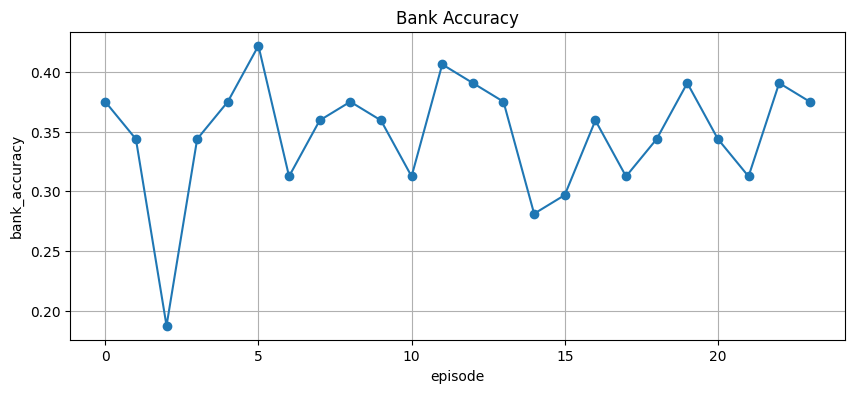

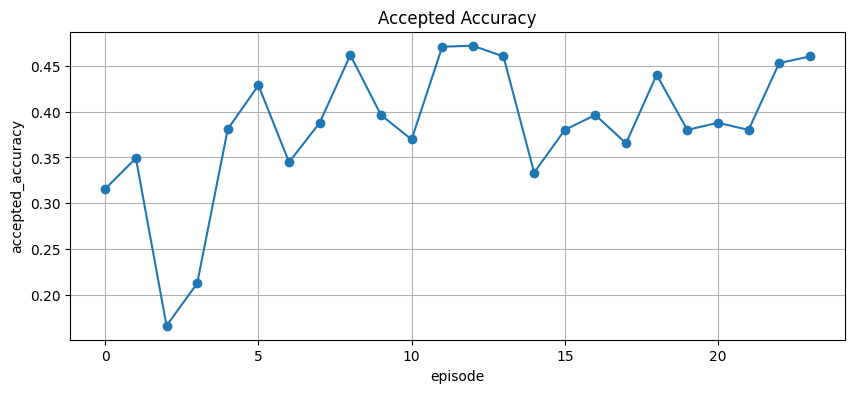

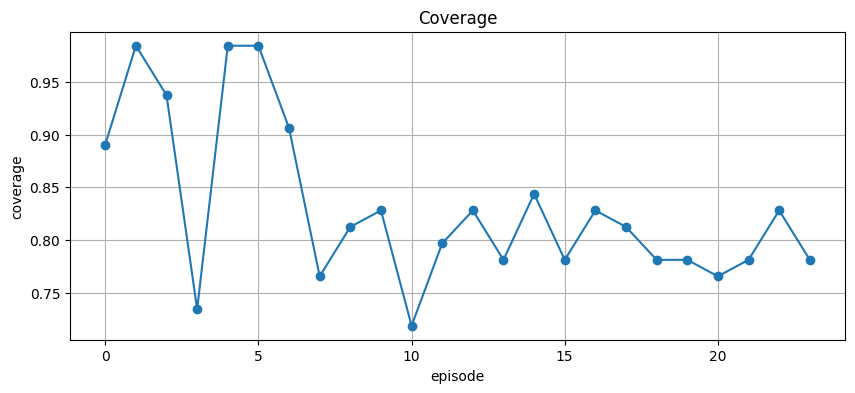

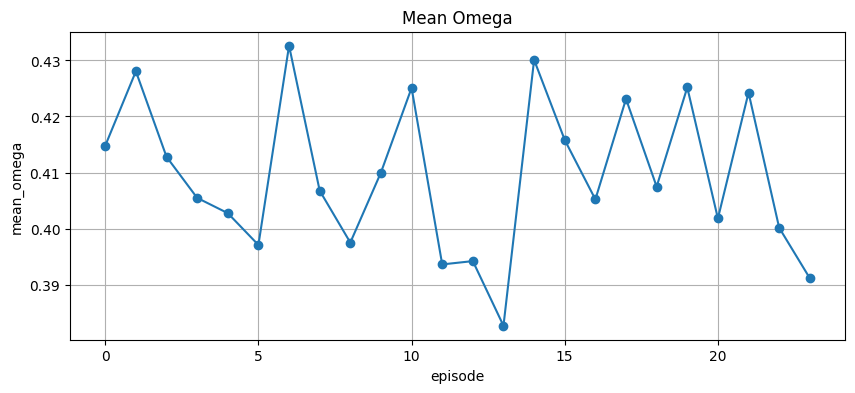

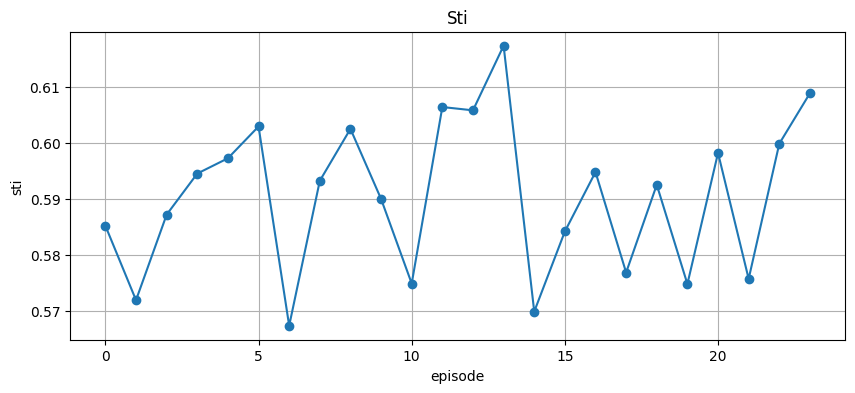

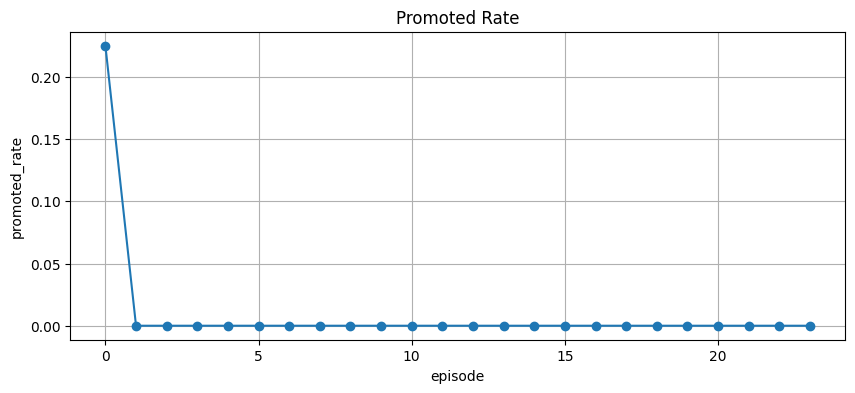

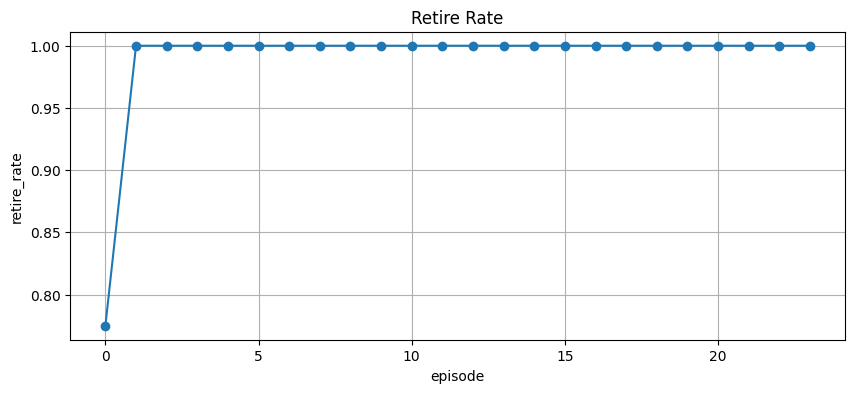

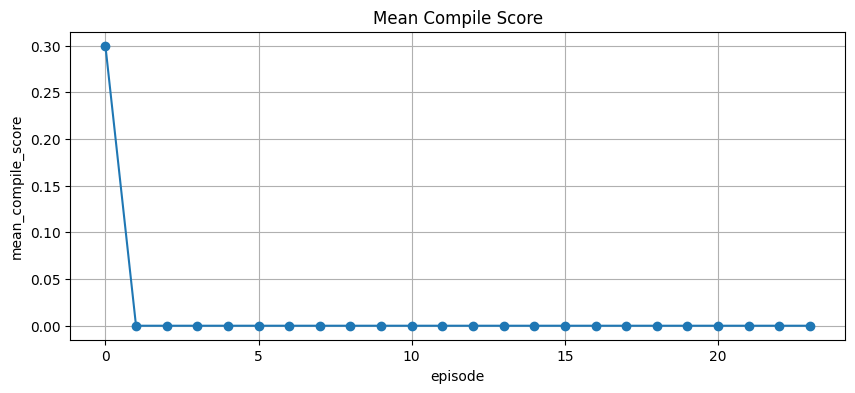

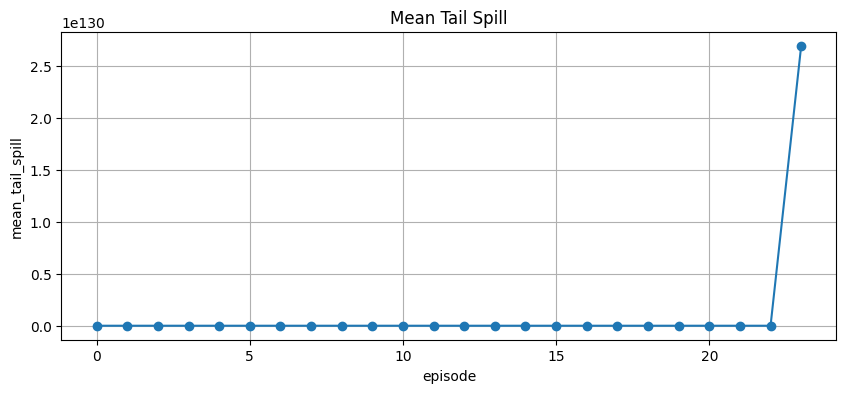

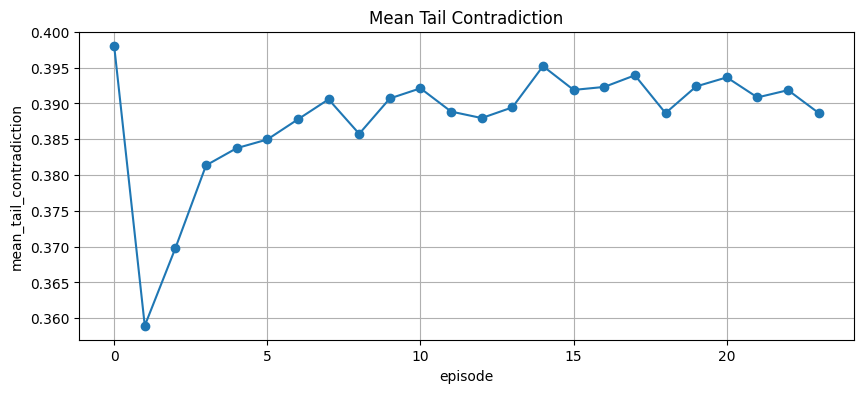

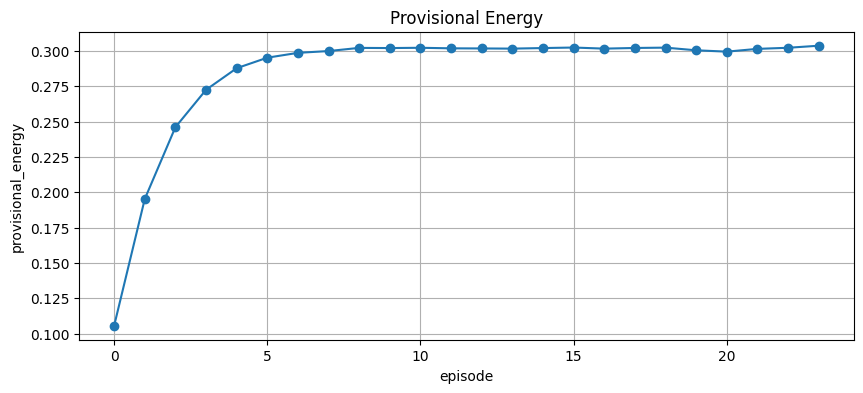

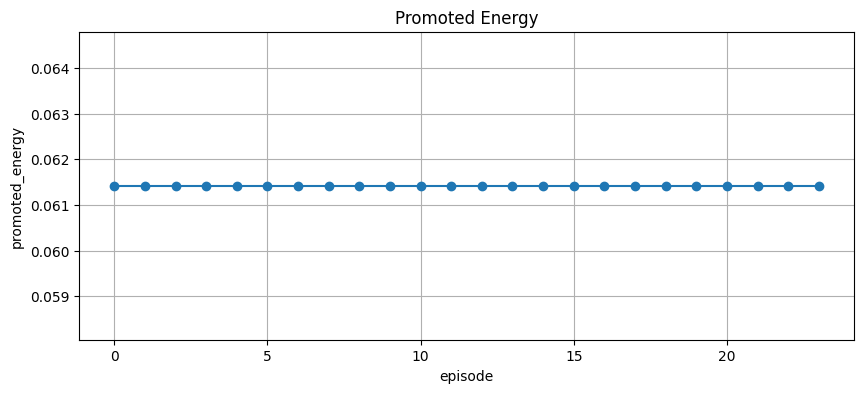

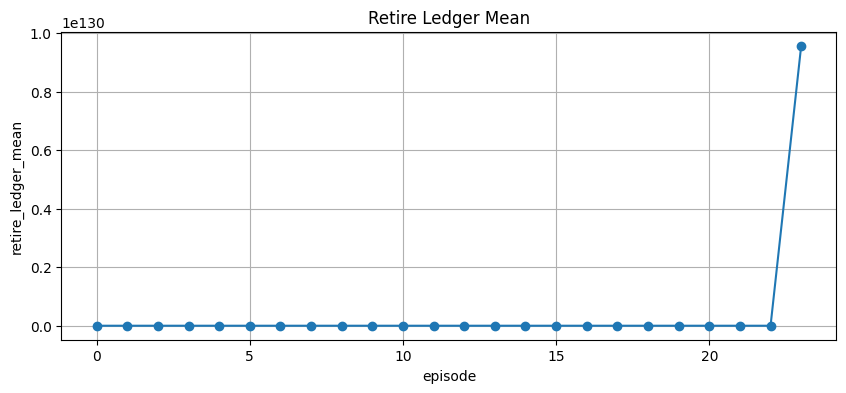

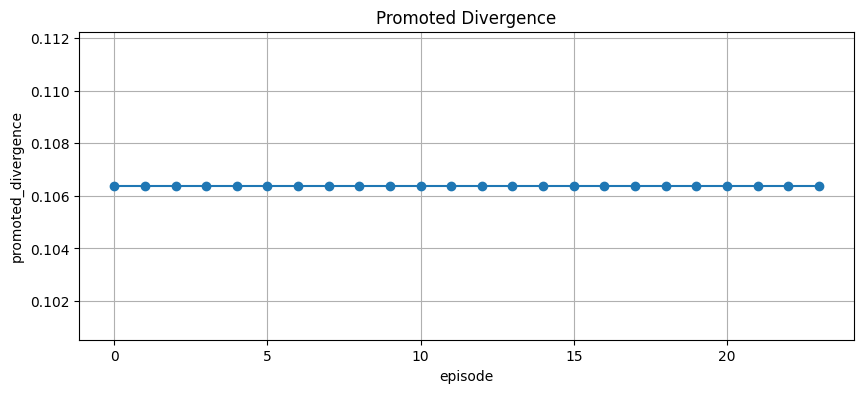

In [9]:

metrics = [
    "bank_accuracy",
    "accepted_accuracy",
    "coverage",
    "mean_omega",
    "sti",
    "promoted_rate",
    "retire_rate",
    "mean_compile_score",
    "mean_tail_spill",
    "mean_tail_contradiction",
    "provisional_energy",
    "promoted_energy",
    "retire_ledger_mean",
    "promoted_divergence",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    plt.plot(results["episode"], results[metric], marker="o")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("episode")
    plt.ylabel(metric)
    plt.show()



## Tail-log summary

This is the real new object:
the runtime keeps compile history rather than only answer collapse.


In [10]:

tail_df = pd.DataFrame([asdict(r) for r in runtime.tail_log])
tail_df.head()


,episode,trial,target_slot,predicted_slot,route_margin,contradiction,reproducibility_error,budget,spill,compile_score,promoted,retired
0,0,0,0,3,0.000000,0.534185,0.056465,0.050745,0.000000,0.740712,False,True
1,0,1,0,0,0.972229,0.350177,0.059688,0.043734,0.122144,0.799494,True,False
2,0,2,0,0,0.989773,0.251617,0.061538,0.037203,0.132100,0.842464,True,False
3,0,3,0,0,0.990731,0.208404,0.058536,0.031900,0.141736,0.861379,True,False
4,0,4,0,0,0.991535,0.185745,0.058951,0.027960,0.148770,0.870676,True,False


In [11]:

tail_summary = pd.DataFrame([{
    "promotion_rate": float(tail_df["promoted"].mean()),
    "retire_rate": float(tail_df["retired"].mean()),
    "mean_compile_score": float(tail_df["compile_score"].mean()),
    "mean_contradiction": float(tail_df["contradiction"].mean()),
    "mean_repro_error": float(tail_df["reproducibility_error"].mean()),
    "mean_budget": float(tail_df["budget"].mean()),
    "mean_spill": float(tail_df["spill"].mean()),
    "order_match_rate": float((tail_df["predicted_slot"] == tail_df["target_slot"]).mean()),
}])
tail_summary


,promotion_rate,retire_rate,mean_compile_score,mean_contradiction,mean_repro_error,mean_budget,mean_spill,order_match_rate
0,0.009375,0.990625,0.012497,0.3879,0.010918,0.027922,1.122466e+129,0.248958



## Early vs late summary


In [12]:

early = results.iloc[:6]
late = results.iloc[-6:]

summary_df = pd.DataFrame([{
    "bank_accuracy_gain": float(late["bank_accuracy"].mean() - early["bank_accuracy"].mean()),
    "accepted_accuracy_gain": float(late["accepted_accuracy"].mean() - early["accepted_accuracy"].mean()),
    "coverage_gain": float(late["coverage"].mean() - early["coverage"].mean()),
    "omega_gain": float(early["mean_omega"].mean() - late["mean_omega"].mean()),
    "sti_gain": float(late["sti"].mean() - early["sti"].mean()),
    "promoted_rate_gain": float(late["promoted_rate"].mean() - early["promoted_rate"].mean()),
    "retire_rate_gain": float(late["retire_rate"].mean() - early["retire_rate"].mean()),
    "compile_score_gain": float(late["mean_compile_score"].mean() - early["mean_compile_score"].mean()),
    "tail_spill_drop": float(early["mean_tail_spill"].mean() - late["mean_tail_spill"].mean()),
    "contradiction_drop": float(early["mean_tail_contradiction"].mean() - late["mean_tail_contradiction"].mean()),
    "promoted_energy_gain": float(late["promoted_energy"].mean() - early["promoted_energy"].mean()),
    "retire_ledger_drop": float(early["retire_ledger_mean"].mean() - late["retire_ledger_mean"].mean()),
}])
summary_df


,bank_accuracy_gain,accepted_accuracy_gain,coverage_gain,omega_gain,sti_gain,promoted_rate_gain,retire_rate_gain,compile_score_gain,tail_spill_drop,contradiction_drop,promoted_energy_gain,retire_ledger_drop
0,0.018229,0.107772,-0.132812,0.001824,0.001824,-0.0375,0.0375,-0.049987,-4.489866e+129,-0.01153,0.0,-1.595945e+129



## Read the result

This notebook should now answer a different question:

- are more tails being **promoted** over time?
- are failed tails being **retired** rather than simply accumulating?
- does promoted memory become cleaner while provisional burden falls?
- do passive omega/STI move as a consequence?

That is the first direct implementation of:
- tail-first execution
- validation boundary
- compile-minus-retire
- semantic memory + tail memory
